# Stress Testing

In [1]:
import sys
sys.path.append('../src')

from risk_model.notebook_helpers import fetch_market_data
from risk_model.chart_config import setup_chart_style, COLORS
from risk_model.config import load_markets_config
from risk_model.scenarios import simulate_liquidation_cascade, simulate_liquidity_gap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

setup_chart_style()

## 1. Load Data

In [2]:
markets_config = load_markets_config()
markets = markets_config['markets']
market_data = fetch_market_data(markets, lookback_days=30, limit_markets=5)
test_markets = list(market_data.keys())[:4]
print(f"Markets: {', '.join(test_markets)}")

Markets: ETH-PERP, BTC-PERP, SOL-PERP, ARB-PERP


## 2. Liquidation Cascade (Fixed USD)

In [3]:
# Test fixed USD liquidation amounts
liquidation_amounts = [1_000_000, 5_000_000, 10_000_000, 25_000_000, 50_000_000]
cascade_results = []

for market in test_markets:
    if market in market_data and 'orderbook' in market_data[market]:
        for liq_usd in liquidation_amounts:
            result = simulate_liquidation_cascade(
                market_data[market]['orderbook'],
                liquidation_usd=liq_usd
            )
            if 'error' not in result:
                result['market'] = market
                cascade_results.append(result)

cascade_df = pd.DataFrame(cascade_results)
display(cascade_df[['market', 'liquidation_usd', 'price_impact_pct', 'slippage_pct', 'levels_consumed', 'pct_of_depth_consumed']])

,market,liquidation_usd,price_impact_pct,slippage_pct,levels_consumed,pct_of_depth_consumed
0,ETH-PERP,1000000,0.0014,0.0003,5,27.45
1,ETH-PERP,5000000,0.0440,0.0208,146,137.25
2,ETH-PERP,10000000,0.0691,0.0352,229,274.50
3,ETH-PERP,25000000,0.1531,0.0720,500,686.25
4,ETH-PERP,50000000,0.1531,0.0720,500,1372.49
5,BTC-PERP,1000000,0.0001,0.0001,1,26.12
6,BTC-PERP,5000000,0.0192,0.0075,141,130.61
7,BTC-PERP,10000000,0.0423,0.0194,322,261.22
8,BTC-PERP,25000000,0.0662,0.0318,500,653.05
9,BTC-PERP,50000000,0.0662,0.0318,500,1306.10


## 3. Cascade Impact Chart

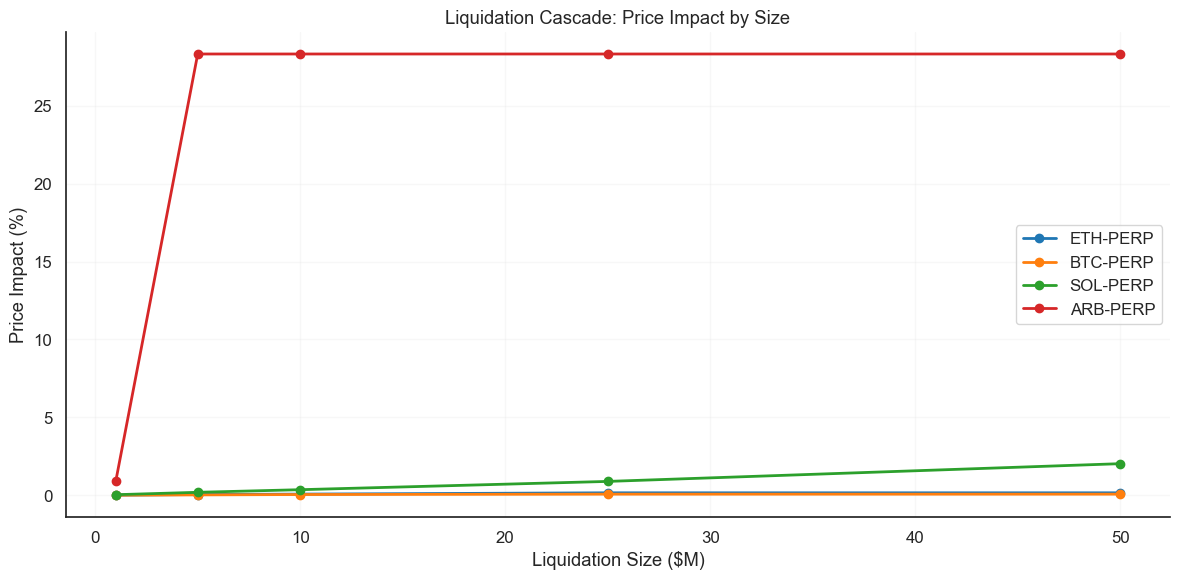

In [4]:
fig, ax = plt.subplots(figsize=(12, 6))

for market in test_markets:
    market_df = cascade_df[cascade_df['market'] == market]
    ax.plot(
        market_df['liquidation_usd'] / 1e6,
        market_df['price_impact_pct'],
        marker='o',
        linewidth=2,
        label=market
    )

ax.set_xlabel('Liquidation Size ($M)')
ax.set_ylabel('Price Impact (%)')
ax.set_title('Liquidation Cascade: Price Impact by Size')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Gap Risk Analysis

In [5]:
gap_scenarios = [0.05, 0.10, 0.15, 0.20]  # 5%, 10%, 15%, 20%
gap_results = []

for market in test_markets:
    if market in market_data and 'orderbook' in market_data[market]:
        for gap_size in gap_scenarios:
            result = simulate_liquidity_gap(
                market_data[market]['orderbook'],
                gap_size=gap_size,
                direction='down'
            )
            result['market'] = market
            gap_results.append(result)

gap_df = pd.DataFrame(gap_results)
display(gap_df[['market', 'gap_size', 'unfilled_volume_pct', 'unfilled_orders']])

,market,gap_size,unfilled_volume_pct,unfilled_orders
0,ETH-PERP,0.05,100.000000,500
1,ETH-PERP,0.10,100.000000,500
2,ETH-PERP,0.15,100.000000,500
3,ETH-PERP,0.20,100.000000,500
4,BTC-PERP,0.05,100.000000,500
5,BTC-PERP,0.10,100.000000,500
6,BTC-PERP,0.15,100.000000,500
7,BTC-PERP,0.20,100.000000,500
8,SOL-PERP,0.05,100.000000,500
9,SOL-PERP,0.10,100.000000,500


## 5. Gap Impact Chart

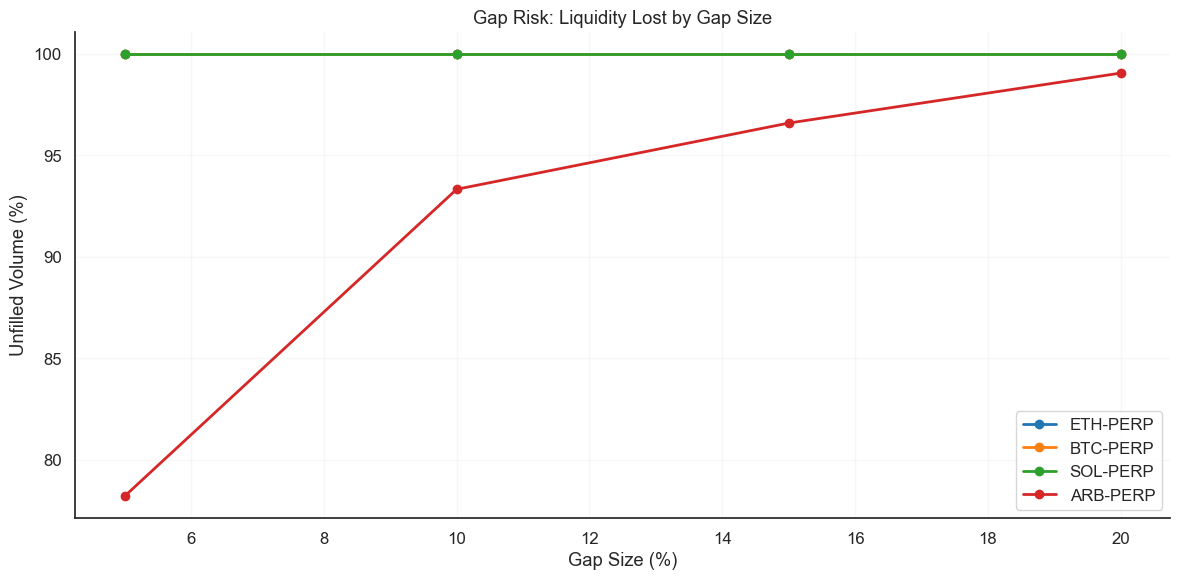

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))

for market in test_markets:
    market_df = gap_df[gap_df['market'] == market]
    ax.plot(
        market_df['gap_size'] * 100,
        market_df['unfilled_volume_pct'],
        marker='o',
        linewidth=2,
        label=market
    )

ax.set_xlabel('Gap Size (%)')
ax.set_ylabel('Unfilled Volume (%)')
ax.set_title('Gap Risk: Liquidity Lost by Gap Size')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Summary Table

In [7]:
# Summary: impact of $10M liquidation per market
summary_df = cascade_df[cascade_df['liquidation_usd'] == 10_000_000][['market', 'price_impact_pct', 'slippage_pct', 'total_bid_depth_usd']].copy()
summary_df.columns = ['Market', 'Price Impact (%)', 'Slippage (%)', 'Total Bid Depth ($)']
summary_df['Total Bid Depth ($)'] = summary_df['Total Bid Depth ($)'].apply(lambda x: f"${x/1e6:.1f}M")
print("Impact of $10M Liquidation:")
display(summary_df)

Impact of $10M Liquidation:


,Market,Price Impact (%),Slippage (%),Total Bid Depth ($)
2,ETH-PERP,0.0691,0.0352,$3.6M
7,BTC-PERP,0.0423,0.0194,$3.8M
12,SOL-PERP,0.3530,0.1756,$20.0M
17,ARB-PERP,28.3234,3.6191,$2.7M
